In [1]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
df = pd.read_parquet("../data/processed/bankruptcy.parquet")

X = df.drop(columns=["class"])

In [3]:
X_transformed = np.sign(X) * np.log1p(np.abs(X))

In [4]:
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X_transformed)

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

In [6]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [7]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance[:10])

[0.27664072 0.11368239 0.09004468 0.07888321 0.04658408 0.04557648
 0.04164104 0.03324801 0.02680486 0.02248291]


In [8]:
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance[:20])

[0.27664072 0.39032311 0.48036779 0.559251   0.60583508 0.65141156
 0.6930526  0.72630061 0.75310547 0.77558837 0.79614905 0.81346857
 0.82971365 0.84593499 0.86022021 0.8732352  0.88502327 0.8956669
 0.90541155 0.91470351]


In [9]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(n_components_90)

19


In [10]:
inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )

    kmeans.fit(X_pca[:, :10])

    inertias.append(kmeans.inertia_)

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

for pc in ["PC1", "PC2", "PC3"]:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
Attr62    0.189248
Attr12    0.182398
Attr63    0.178575
Attr16    0.175325
Attr26    0.174655
Attr32    0.173669
Attr2     0.171922
Attr24    0.169126
Attr4     0.167705
Attr50    0.167685
Name: PC1, dtype: float64

PC2
Attr36    0.245987
Attr11    0.230377
Attr9     0.228623
Attr8     0.224628
Attr17    0.223433
Attr7     0.219009
Attr18    0.219009
Attr14    0.219009
Attr22    0.217851
Attr4     0.214785
Name: PC2, dtype: float64

PC3
Attr13    0.290764
Attr31    0.283530
Attr19    0.283502
Attr23    0.280020
Attr43    0.234682
Attr39    0.234591
Attr42    0.210358
Attr44    0.201168
Attr33    0.196725
Attr32    0.193185
Name: PC3, dtype: float64


In [12]:
X = df.drop(columns=["class"])

[336435.9495943249, 294904.5684539445, 272520.3672447023, 253033.23809111488, 239145.21904196468, 224073.7660148776, 214137.82365416514, 205621.37414103828, 201701.4759539395]


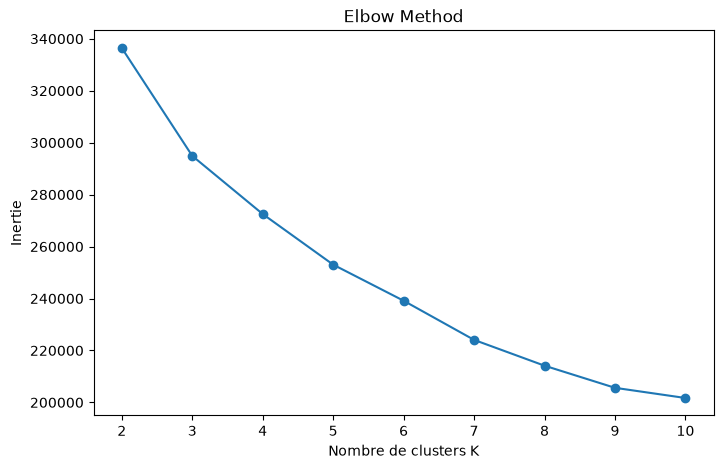

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_pca[:, :19])
    inertias.append(kmeans.inertia_)

print(inertias)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie")
plt.title("Elbow Method")
plt.show()

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca[:, :19])

    score = silhouette_score(
        X_pca[:, :19],
        labels
    )

    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K={k}: silhouette={score:.4f}")

K=2: silhouette=0.2401
K=3: silhouette=0.2285
K=4: silhouette=0.1444
K=5: silhouette=0.1456
K=6: silhouette=0.1258
K=7: silhouette=0.1306
K=8: silhouette=0.1406
K=9: silhouette=0.1064
K=10: silhouette=0.1411


In [16]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans_2.fit_predict(X_pca[:, :19])

df_clustered = df.copy()
df_clustered["cluster"] = clusters

print(df_clustered["cluster"].value_counts())

print(
    df_clustered.groupby("cluster")["class"]
    .agg(["count", "mean", "sum"])
)

cluster
1    4706
0    2239
Name: count, dtype: int64
         count      mean  sum
cluster                      
0         2239  0.017865   40
1         4706  0.049086  231


In [17]:
profile = df_clustered.groupby("cluster")[X.columns].median().T

profile["difference"] = profile[1] - profile[0]

profile.sort_values(
    "difference",
    key=abs,
    ascending=False
).head(15)

cluster,0,1,difference
Attr55,3804.60000,833.925000,-2970.675000
Attr15,323.15000,1546.200000,1223.050000
Attr5,47.18200,-26.445500,-73.627500
Attr32,42.86250,97.642000,54.779500
Attr62,36.88200,89.766500,52.884500
Attr43,84.12600,100.205000,16.079000
Attr20,27.74600,39.318000,11.572000
Attr47,32.48900,41.796000,9.307000
Attr63,9.82130,4.064850,-5.756450
Attr37,8.22130,2.749700,-5.471600


In [19]:
cluster_profile = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

cluster_profile["cluster"] = clusters

profile_z = cluster_profile.groupby("cluster").mean().T

profile_z["difference"] = profile_z[1] - profile_z[0]

profile_z.sort_values(
    "difference",
    key=abs,
    ascending=False
).head(15)

cluster,0,1,difference
Attr50,0.950910,-0.452420,-1.403330
Attr4,0.936672,-0.445646,-1.382318
Attr12,0.936206,-0.445424,-1.381630
Attr16,0.936121,-0.445384,-1.381505
Attr46,0.930152,-0.442543,-1.372695
Attr8,0.921573,-0.438462,-1.360035
Attr26,0.914000,-0.434859,-1.348859
Attr63,0.902818,-0.429539,-1.332356
Attr17,0.896179,-0.426380,-1.322559
Attr5,0.868231,-0.413083,-1.281314


In [20]:
cluster_profile = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

cluster_profile["cluster"] = clusters

profile_z = cluster_profile.groupby("cluster").mean().T

profile_z["difference"] = profile_z[1] - profile_z[0]

profile_z.sort_values(
    "difference",
    key=abs,
    ascending=False
).head(15)


cluster,0,1,difference
Attr50,0.950910,-0.452420,-1.403330
Attr4,0.936672,-0.445646,-1.382318
Attr12,0.936206,-0.445424,-1.381630
Attr16,0.936121,-0.445384,-1.381505
Attr46,0.930152,-0.442543,-1.372695
Attr8,0.921573,-0.438462,-1.360035
Attr26,0.914000,-0.434859,-1.348859
Attr63,0.902818,-0.429539,-1.332356
Attr17,0.896179,-0.426380,-1.322559
Attr5,0.868231,-0.413083,-1.281314


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    "software cloud artificial intelligence",
    "software cloud banking",
    "banking financial services",
    "financial services insurance",
    "cloud software technology"
]

y = [0, 1, 1, 1, 0]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)
vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(texts)

print(X_tfidf.shape)
print(vectorizer.get_feature_names_out())

import pandas as pd

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df

(5, 9)
['artificial' 'banking' 'cloud' 'financial' 'insurance' 'intelligence'
 'services' 'software' 'technology']


,artificial,banking,cloud,financial,insurance,intelligence,services,software,technology
0,0.587521,0.000000,0.393470,0.000000,0.000000,0.587521,0.000000,0.393470,0.000000
1,0.000000,0.648463,0.538283,0.000000,0.000000,0.000000,0.000000,0.538283,0.000000
2,0.000000,0.577350,0.000000,0.577350,0.000000,0.000000,0.577350,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.531772,0.659118,0.000000,0.531772,0.000000,0.000000
4,0.000000,0.000000,0.486240,0.000000,0.000000,0.000000,0.000000,0.486240,0.726044


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression())
])

In [29]:
pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

print(predictions)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions, zero_division=0))

[1 1]
[[0 1]
 [0 1]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

